In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# add path to utils/
from pathlib import Path
import sys

project_root = Path().resolve().parent
sys.path.append(str(project_root))

# import functions from utils/
from utils.importance_sampling import *
from utils.utility import *
from utils.rejection_sampling import *

from scipy.stats import uniform, norm, cauchy

In [5]:
# q1
n_samples = 10_000
x = np.random.exponential(scale=1/3, size=n_samples)
samples = np.cos(x)
2/3 * np.mean(samples)
# 0.600

np.float64(0.6004274300502086)

In [ ]:
# q2
n_samples = 100_000
u = np.random.uniform(0, 1, size=(n_samples, 10))
samples = np.max(u, axis=1)
np.mean(samples)
# 0.909

np.float64(0.9086748072812193)

In [ ]:
# q3
n_samples = 100_000
toss_count = np.empty(n_samples)
for i in range(n_samples):
    count = 0
    consec = 0
    while True:
        toss = np.random.choice([0, 1])
        count += 1
        if toss == 1:
            consec += 1
        else:
            consec = 0

        if consec == 3:
            toss_count[i] = count
            break
    
np.mean(toss_count)
# 14.01

np.float64(14.01731)

In [ ]:
# q4
x = np.random.standard_cauchy(n_samples)
samples = np.pi / np.sqrt(5) * np.cos(1/np.sqrt(5) * x)
np.mean(samples)
# 0.894

np.float64(0.8944470153637218)

In [ ]:
# q5
x = np.random.exponential(scale=1/2, size=n_samples)
samples = 1/2 * np.cos(np.sqrt(x))
generate_mean_and_std_err(samples)
# 0.3853

Mean: 0.3853
Standard Error: 0.0003


In [22]:
# q6
x = np.random.uniform(0, 3, n_samples)
y = np.random.uniform(0, 3, n_samples)

ratios = np.exp(x * y)
normalised_weights = ratios / np.sum(ratios)

ess = 1 / np.sum(normalised_weights**2)
print("ESS: ", ess)

est = np.sum((x + y) * normalised_weights)
print("Mean: ", est)
# 1.92

ESS:  6075.41650206312
Mean:  5.215259159965556


ESS:  70560.59037798735
Mean:  0.835891492811017


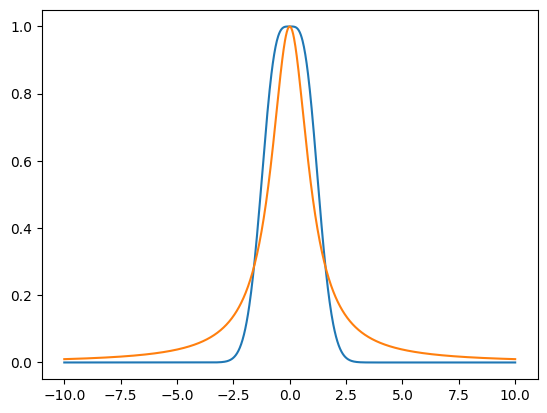

In [ ]:
# q7
x = np.linspace(-10, 10, 1000)
y = (1 + x**2) * np.exp(-x**2)
z = 1 / (1 + x**2)
plt.plot(x, y)
plt.plot(x, z)

x = np.random.standard_cauchy(n_samples)
samples = x**2
ratios = (1 + x**2)**2 * np.exp(-x**2)
weights = ratios / np.sum(ratios)

ess = 1 / np.sum(weights**2)
est = np.sum(samples * weights)

print("ESS: ", ess)
print("Mean: ", est)
# 0.835

In [ ]:
# q8
x = np.random.standard_cauchy(n_samples) + 1
y = np.random.standard_cauchy(n_samples) + 1

samples = x**3 + y**3 > 100

log_ratios = (-x**2/2 - y**2/2) + np.log(1 + (x - 1)**2) + np.log(1 + (y - 1)**2)
ratios = np.exp(log_ratios)
weights = ratios / np.sum(ratios)
est = np.sum(samples * weights)
print(1e5 * est)
# 0.365

# when dealing with very small values you should work in log ratios and then exp()

0.3534472488863989


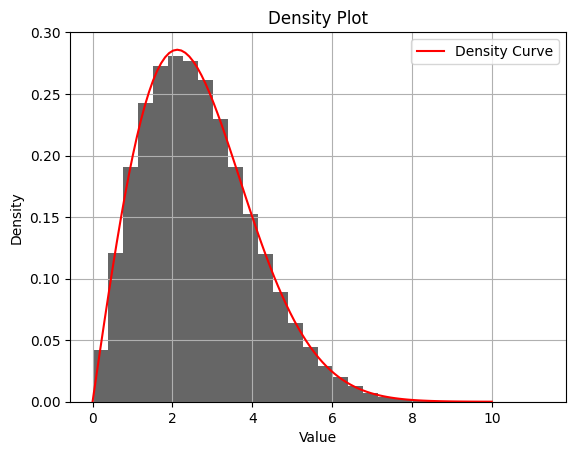

In [101]:
# q9
u = np.random.uniform(0, 1, n_samples)
samples = 3 * np.sqrt(np.log(1 / (1 - u)))
plot_density(samples, lambda x: 2/3 * x * np.exp(-(x/3)**2), x_min=0, x_max=10)

In [103]:
print(f"{np.mean(samples):3f}")

2.659796


In [ ]:
# q10
u = np.random.uniform(0, 2, n_samples)
samples = u**4
ratios = u**2 * (2 - u)**3
weights = ratios / np.sum(ratios)

ess = 1 / np.sum(weights**2)
est = np.sum(samples * weights)

print("ess: ", ess)
print("mean: ", est)
# 1.144

ess:  64197.40849371279
mean:  1.1443042567931112


1000 / 10000 samples accepted.
2000 / 10000 samples accepted.
3000 / 10000 samples accepted.
4000 / 10000 samples accepted.
5000 / 10000 samples accepted.
6000 / 10000 samples accepted.
7000 / 10000 samples accepted.
8000 / 10000 samples accepted.
9000 / 10000 samples accepted.
10000 / 10000 samples accepted.
Acceptance Rate: 0.4280


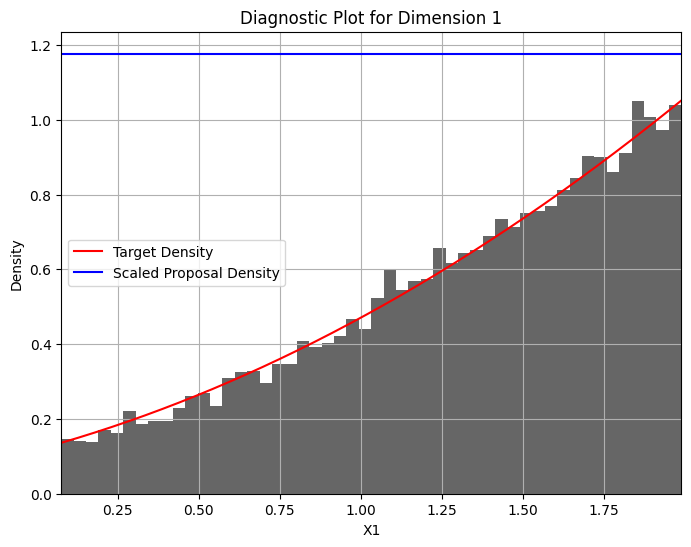

In [112]:
# q11
target_density = lambda x: (1 + x)**2
proposal_density = lambda x: uniform.pdf(x, loc=0, scale=2)
proposal_rvs = lambda : np.random.uniform(0, 2, size=(1,))

samples, acceptance_rate = rejection_sampling(
    target_density,
    proposal_density,
    proposal_rvs,
    M=20,
    n_samples=10_000,
    diagnostics=True
)

In [ ]:
std_est = np.std(samples)
print(std_est)
# 0.504

0.5041082833116287


In [ ]:
# SNIS approach with a uniform(0, 2) proposal
n_samples = 100_000
u = np.random.uniform(0, 2, n_samples)
ratios = (1 + u)**2
weights = ratios / np.sum(ratios)

mu = np.sum(u * weights)
mu2 = np.sum(u**2 * weights)
std = np.sqrt(mu2 - mu**2)
print(std)

0.5086945332254053


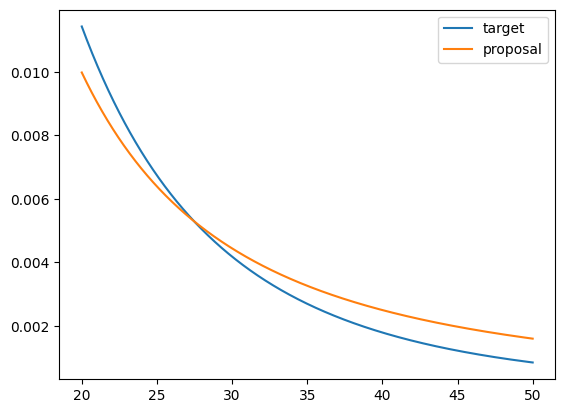

84.09141807031222


In [133]:
# q12
x = np.linspace(20, 50, 1000)
y = np.exp(-np.sqrt(x))
z = 4 / (1 + x**2) # cauchy works
plt.plot(x, y, label="target")
plt.plot(x, z, label="proposal")
plt.legend()
plt.show()

n_samples = 1_000_000
x = np.abs(np.random.standard_cauchy(n_samples))
log_ratios = -np.sqrt(x) + np.log(1 + x**2)
ratios = np.exp(log_ratios)
weights = ratios / np.sum(ratios)

mu = np.sum(x * weights)
mu2 = np.sum(x**2 * weights)
var = mu2 - mu**2
print(var)
# 83.5

In [ ]:
# q13

def generate_one_sample():
    mu=3
    rate = 1/mu
    x = np.random.exponential(scale=mu, size=(5,))
    s = np.sum(x)

    log_ratio = np.sum(-x - np.log(rate) + rate*x)
    ratio = np.exp(log_ratio)
    i = (s > 15).astype(float)

    return i * ratio

samples = [generate_one_sample() for _ in range(100_000)]
np.mean(samples) * 1e4
# 8.5183

np.float64(8.518344515527644)

In [ ]:
# q14
T = 10
z = np.random.normal(loc=1, scale=1, size=(n_samples, 10))
s = np.cumsum(z, axis=1)

log_target = np.sum(-z**2/2, axis=1)
log_proposal = np.sum(-(z - 1)**2/2, axis=1)
log_ratio = log_target - log_proposal
ratio = np.exp(log_ratio)

print(ratio)

i = np.all(s > np.arange(1, 11, 1), axis=1)

prob = np.mean(i * ratio)
print(1e4 * prob)
# 1.50

[3.60791165e-01 3.57362337e-05 1.88296392e-01 ... 9.89391693e-04
 7.08891802e-04 1.43409233e-03]
1.4968961118599882


In [ ]:
# q15
r = np.array([5, 2, 1, 3, 1])
w = r / np.sum(r)
ess = 1/ np.sum(w**2)
print(ess)
# 3.60

3.5999999999999996


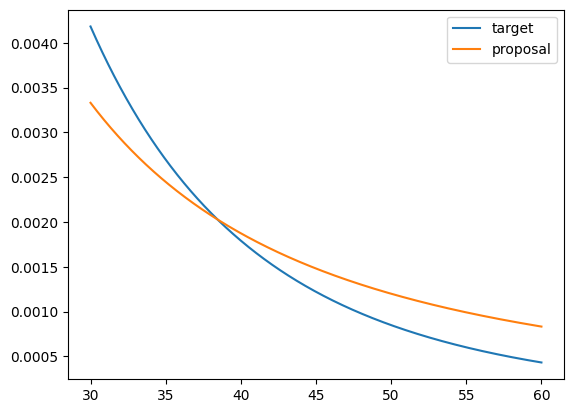

4.001831145866063


In [182]:
# q16
x = np.linspace(30, 60, 1000)
y = np.exp(-np.sqrt(np.abs(x)))
z = 3 / (1 + x**2)
plt.plot(x, y, label="target")
plt.plot(x, z, label="proposal")
plt.legend()
plt.show()

n_samples = 1_000_000
x = np.random.standard_cauchy(n_samples)
g = np.exp(-np.sqrt(np.abs(x))) * np.pi * (1 + x**2)
est = np.mean(g)
print(est)

In [185]:
x = np.random.uniform(0, 1, (n_samples, 2))
y = np.random.uniform(0, 1, (n_samples, 2))
x_diff = x[:, 0] - x[:, 1]
y_diff = y[:, 0] - y[:, 1]
dist = np.sqrt(x_diff**2 + y_diff**2)
generate_mean_and_std_err(dist)
# 0.521

Mean: 0.5215
Standard Error: 0.0002


In [269]:
# q18 (coupled proposal)
n_samples = 1_000_000
sigma_q = 0.01
x = np.random.normal(0, 1, size=n_samples)
z = np.random.normal(0, sigma_q, size=n_samples)
y = x + z

# normalise the weights in log-space
log_target = -(y**2)/2 
log_proposal = -(y - x)**2/(2 * sigma_q**2) - np.log(sigma_q)
log_ratio = log_target - log_proposal
ratio = np.exp(log_ratio)

ind = np.abs(x - y) < 0.01
est = 1e3 * np.mean(ind * ratio)

print(est)


5.633539653106738


In [276]:
# q19
n_samples = 100_000
T = 20
p_biased = 0.7
Z = np.random.choice([-1, 1], p=[1 - p_biased, p_biased], size=(n_samples, T))
S = np.cumsum(Z, axis=1)
S_last = S[:, T - 1]

n_plus = np.sum(Z == 1, axis=1)
n_minus = 20 - n_plus
log_weights = 20 * np.log(0.5) - n_plus * np.log(0.7) - n_minus * np.log(0.3)
weights = np.exp(log_weights)

ind = S_last >= 14

est = 1e4 * np.mean(ind * weights)
print(est)

13.093978890819487


In [ ]:
# q20
K = 10
sd = np.sqrt(2)
X = np.random.normal(0, sd, (n_samples, K))
S = np.sum(X**2, axis=1)

log_ratio = -S/2 + S/(2*sd**2) + K * np.log(sd) # be careful of the density
ratio = np.exp(log_ratio)

ind = S > 30
est = 1e5 * np.mean(ind * ratio) 
print(est)

85.12330106251244
